##### Import the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

##### Load the datasets

In [2]:
ortho_b = pd.read_csv(r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Data\TimeSeries\Orthopaedics_Ward_B_TimeSeries.csv")

In [3]:
ortho_b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3655 entries, 0 to 3654
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   hospital_id     3655 non-null   object 
 1   datetime        3655 non-null   object 
 2   ward            3655 non-null   object 
 3   occupied_beds   3655 non-null   float64
 4   staffed_beds    3655 non-null   float64
 5   occupancy_rate  3655 non-null   float64
dtypes: float64(3), object(3)
memory usage: 171.5+ KB


- Run the ADF test for every hospital

In [4]:
ortho_b["hospital_id"].unique()

array(['HHN-BIR-01', 'HHN-EDI-01', 'HHN-LON-01', 'HHN-LON-02',
       'HHN-MAN-01'], dtype=object)

In [5]:
results = []

for hospital in ortho_b["hospital_id"].unique():
    hospital_data = (ortho_b[ortho_b["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    adf = adfuller(hospital_data["occupied_beds"])
    results.append({"Hospital": hospital, "ADF Statistic": round(adf[0],4), "p-value": round(adf[1],4), 
                    "Stationary": "Yes" if adf[1] < 0.05 else "No"})

adf_results = pd.DataFrame(results)

print(f"ADF Test Results for Orthopedic Ward B Unit Occupied Beds")
adf_results

ADF Test Results for Orthopedic Ward B Unit Occupied Beds


,Hospital,ADF Statistic,p-value,Stationary
0,HHN-BIR-01,-9.4146,0.0000,Yes
1,HHN-EDI-01,-7.1946,0.0000,Yes
2,HHN-LON-01,-3.2580,0.0169,Yes
3,HHN-LON-02,-12.2127,0.0000,Yes
4,HHN-MAN-01,-4.5155,0.0002,Yes


      All five hospitals are stationary, meaning bed occupancy is stable over time and does not show long-term drift.
      Every hospital has a p-value below 0.05, confirming stationarity. London 2 shows the strongest result, while London 1 is still stable but has slightly longer occupancy persistence.
      Orthopedic Ward B follows a predictable pattern because most admissions are planned elective surgeries with standard recovery times.
      Because the data is already stable, no differencing is needed (d = 0)** for forecasting.
      The results support using a SARIMA model, with elective surgery schedules included as additional forecasting information to improve prediction accuracy.


- Autocorrelation (ACF) for all hospitals

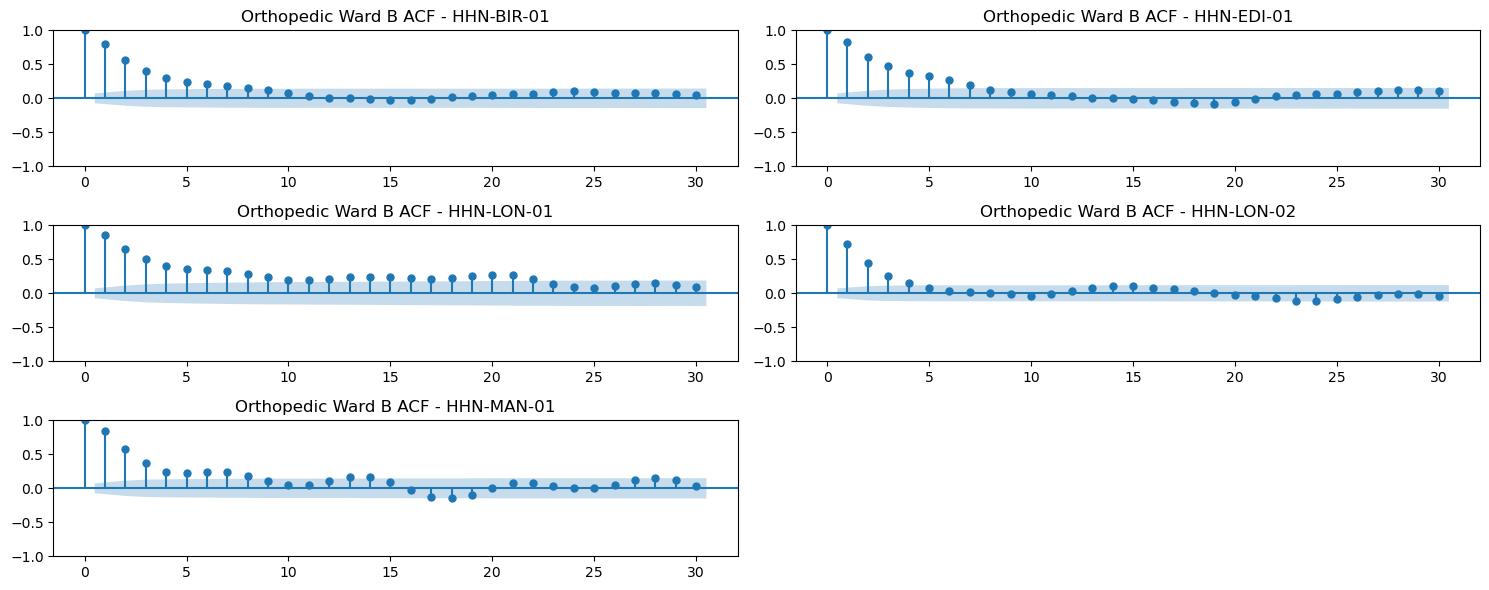

In [6]:
# Create subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 6))
axes = axes.flatten()

# Loop through hospitals
for i, hospital in enumerate(sorted(ortho_b["hospital_id"].unique())):

    hospital_data = (ortho_b[ortho_b["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    plot_acf(hospital_data["occupied_beds"], lags=30,ax=axes[i])
    axes[i].set_title(f"Orthopedic Ward B ACF - {hospital}")

# Remove unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

     Bed occupancy is strongly influenced by the previous few days, but this influence decreases quickly after about 5–7 days.
     All hospitals show a normal decline in autocorrelation, confirming the ADF result that the data is stationary.
     Clear peaks at 7, 14, and 21 days show a strong weekly cycle, reflecting planned elective surgery schedules and weekend discharges.
     Compared with the other hospitals, London 1 shows a slower decline in autocorrelation, suggesting patients stay slightly longer after more complex orthopedic procedures.
     The combination of short-term memory and a weekly cycle makes Orthopedic Ward B highly predictable for forecasting.
     A SARIMA/SARIMAX model is appropriate because it captures both the short-term patient stay pattern and the weekly seasonal cycle.


- PACF for all hospitals

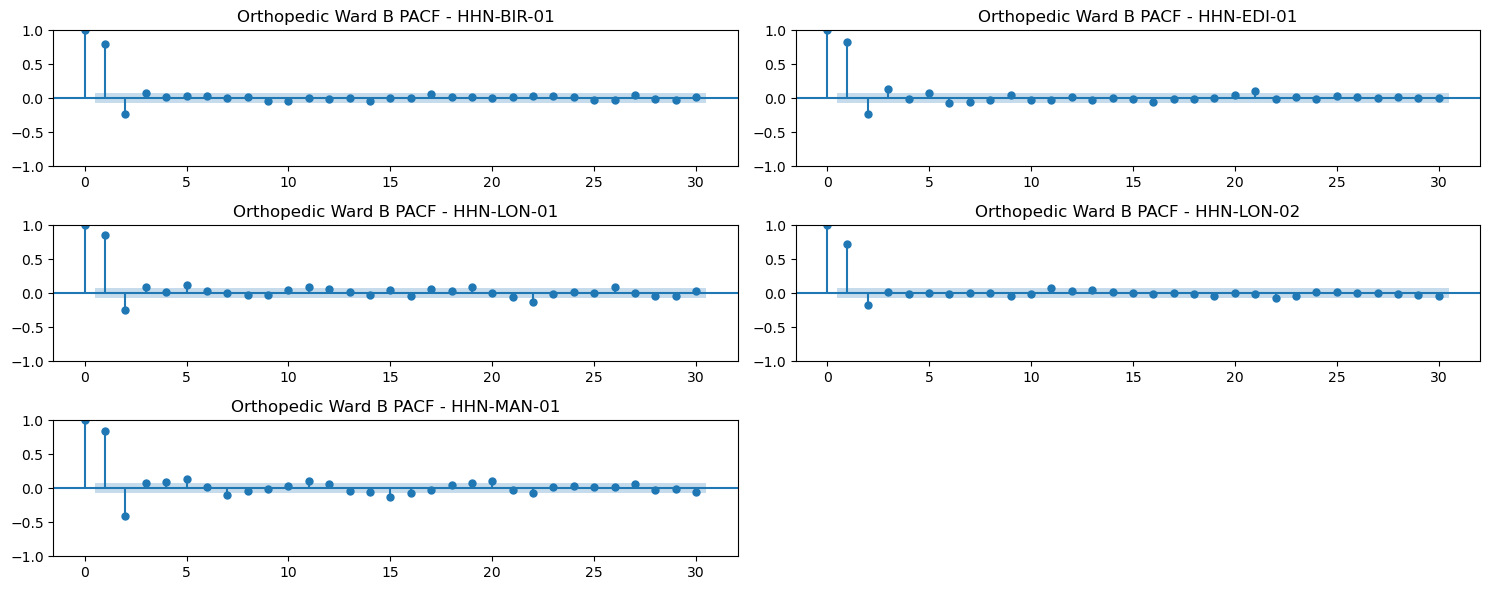

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(15, 6))
axes = axes.flatten()

for i, hospital in enumerate(sorted(ortho_b["hospital_id"].unique())):

    hospital_data = (ortho_b[ortho_b["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    plot_pacf(hospital_data["occupied_beds"], lags=30, ax=axes[i], method="ywm")
    axes[i].set_title(f"Orthopedic Ward B PACF - {hospital}")
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

     All five hospitals are stationary, meaning bed occupancy is stable over time and does not show long-term drift.
     Orthopedic Ward B follows a predictable pattern because most admissions are planned elective surgeries with standard recovery times.
     Patients are typically admitted for scheduled surgery, recover over 2–4 days, and are discharged in a structured manner, making demand easier to forecast.

- Seasonal Decomposition for all hospitals

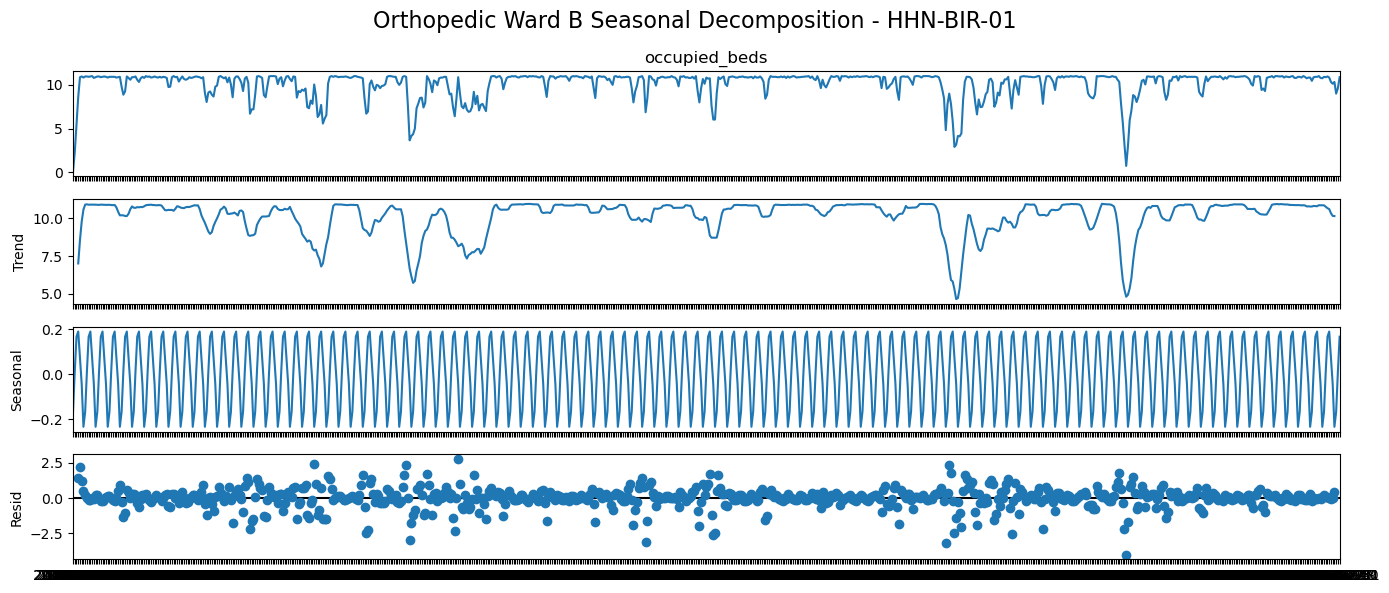

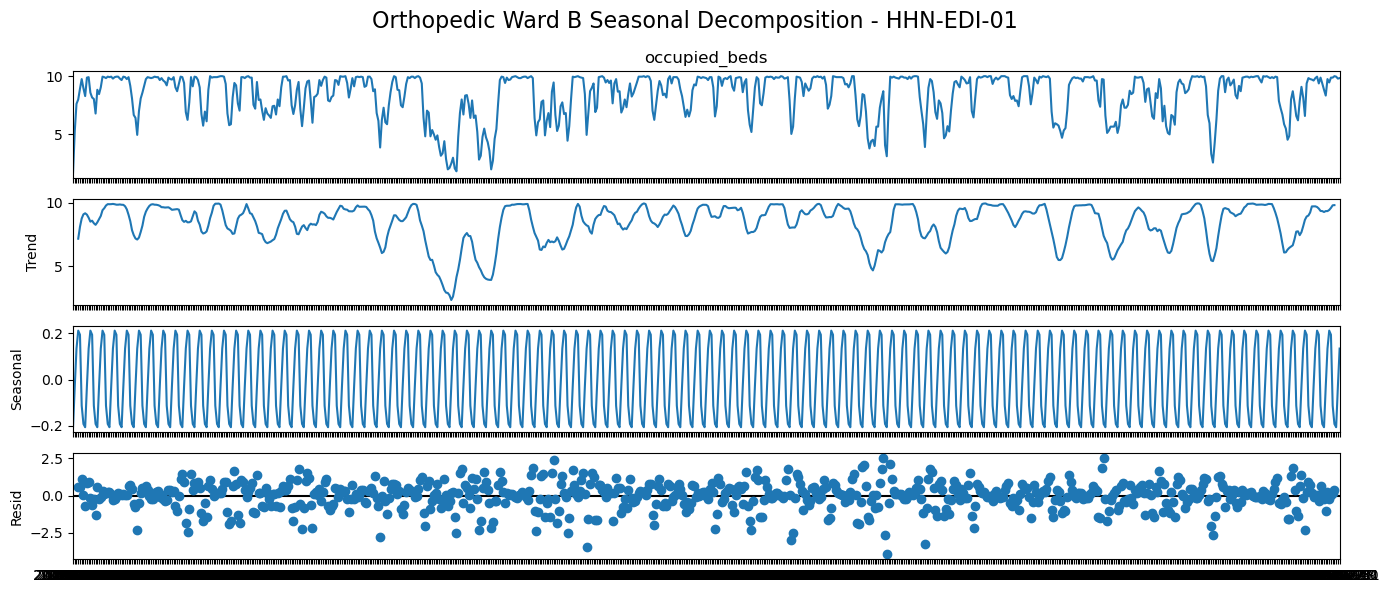

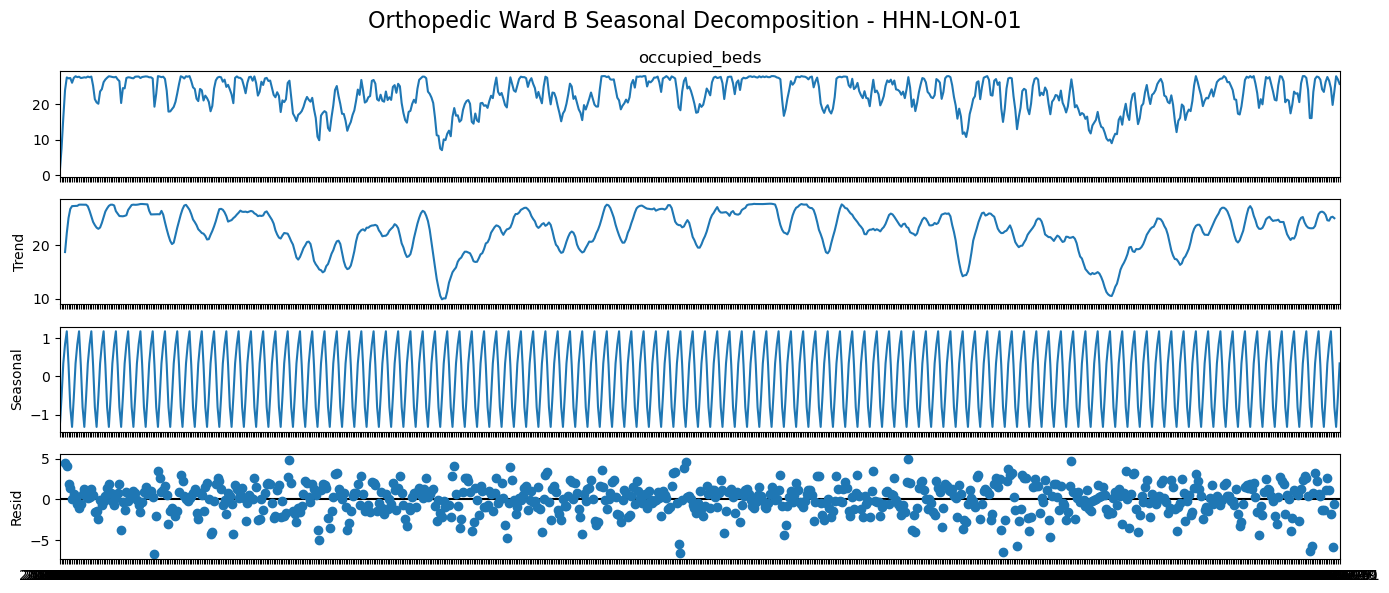

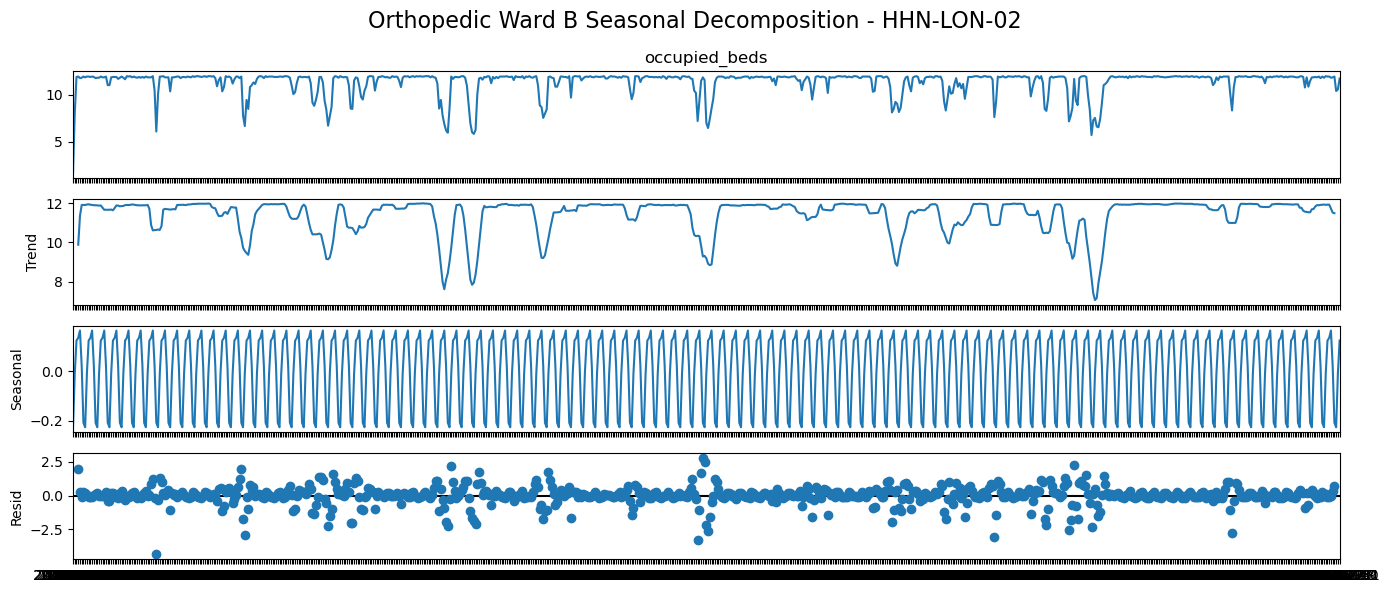

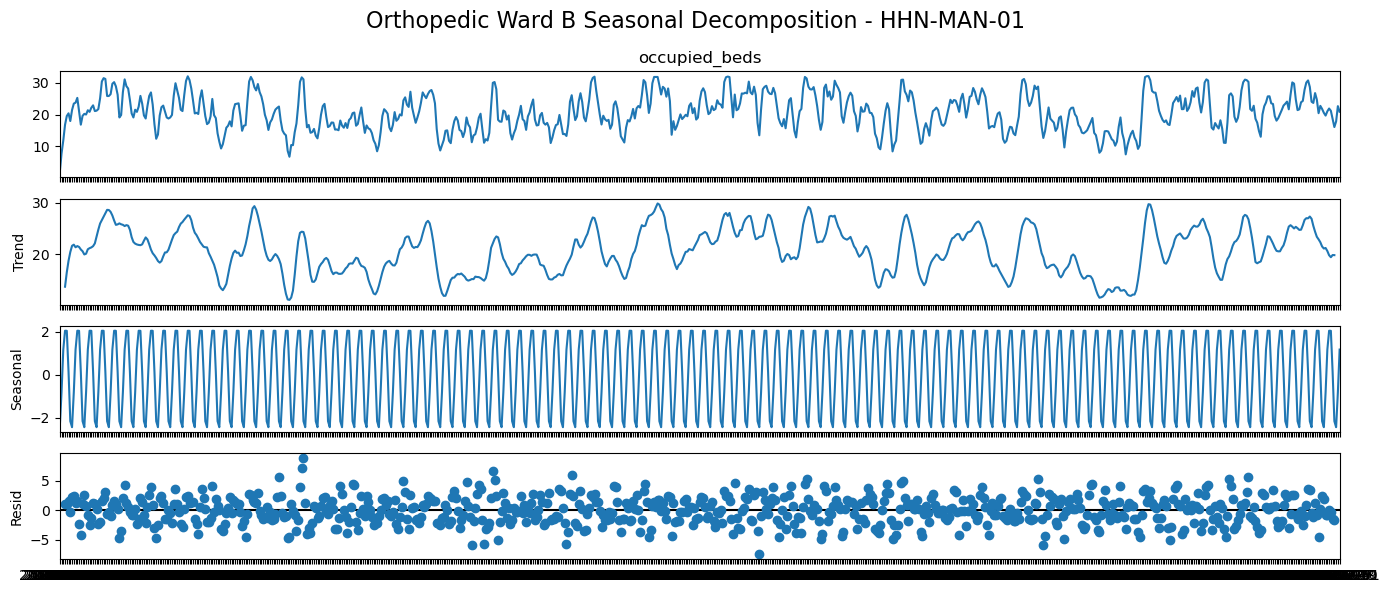

In [8]:
for hospital in sorted(ortho_b["hospital_id"].unique()):

    hospital_data = (ortho_b[ortho_b["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    result = seasonal_decompose(hospital_data["occupied_beds"], model="additive", period=7)
    fig = result.plot()
    fig.set_size_inches(14,6)
    fig.suptitle(f"Orthopedic Ward B Seasonal Decomposition - {hospital}", fontsize=16)
    plt.tight_layout()
    plt.show()

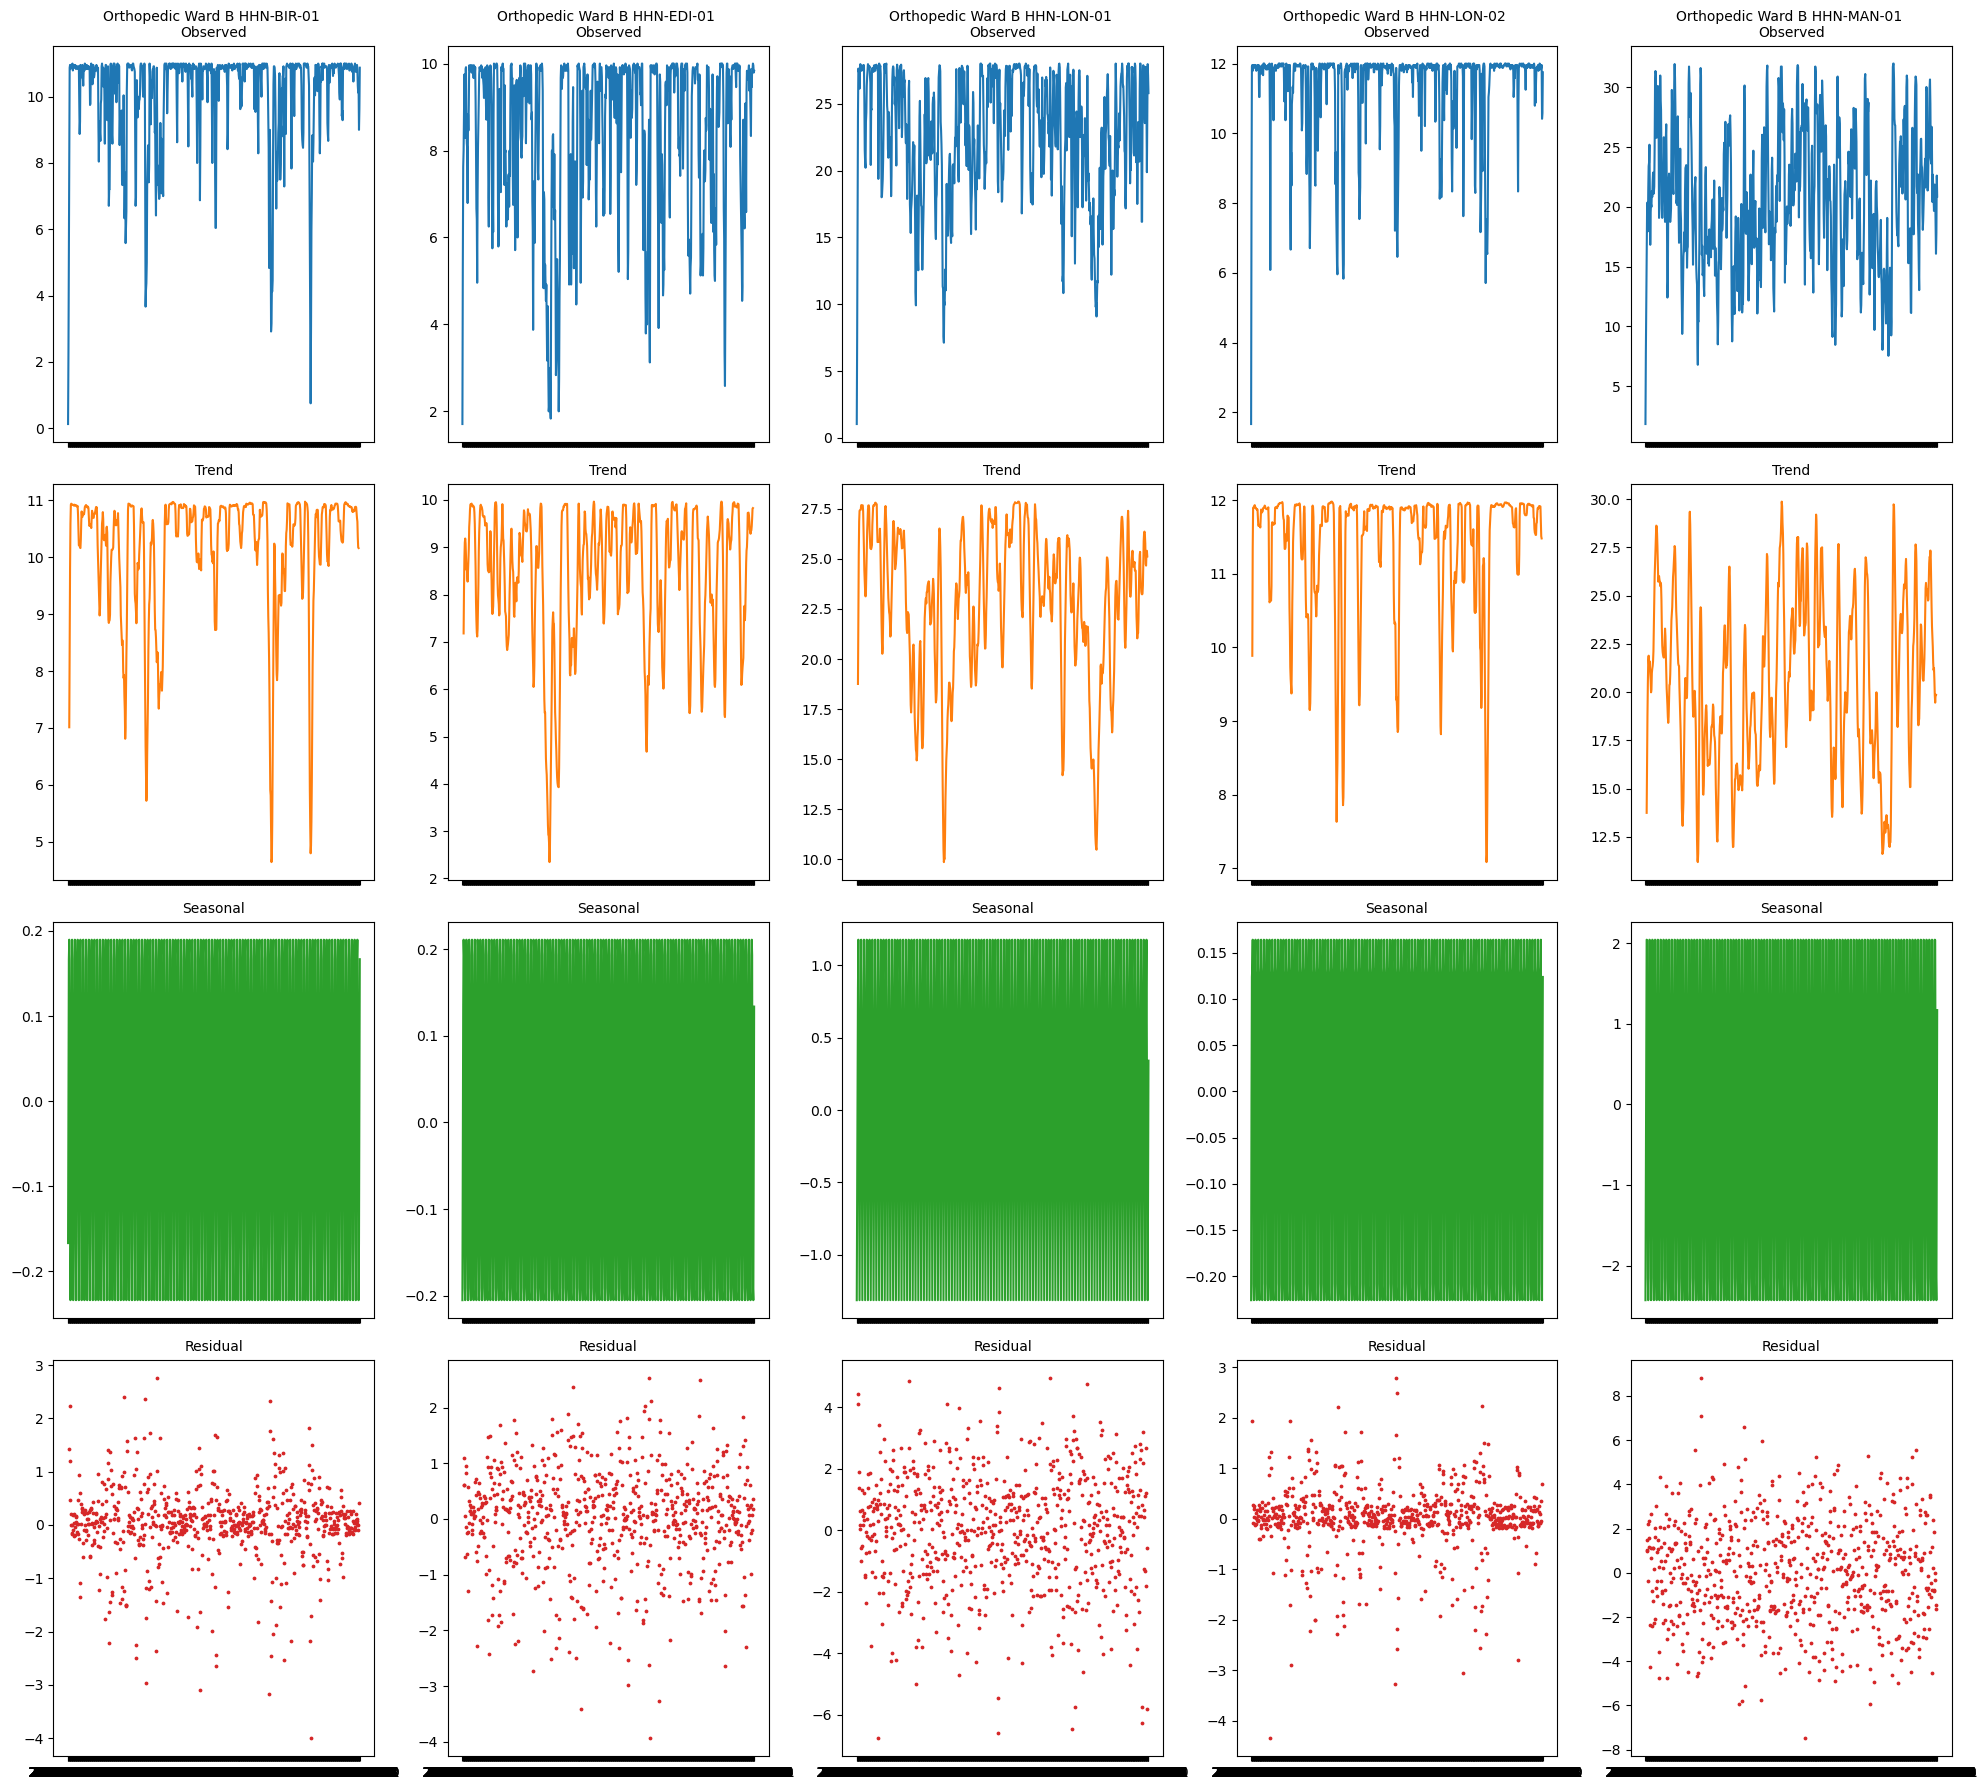

In [9]:
# Create a grid: 4 rows (Observed/Trend/Season/Resid) by X columns (one per hospital)
fig, axes = plt.subplots(4, 5, figsize=(20, 18), sharex=True)

hospitals = sorted(ortho_b["hospital_id"].unique())
for col_idx, hospital in enumerate(hospitals):
    # Filter and decompose data
    hospital_data = ortho_b[ortho_b["hospital_id"] == hospital].sort_values("datetime").set_index("datetime")
    result = seasonal_decompose(hospital_data["occupied_beds"], model="additive", period=7)
    
    # Manually plot each layer into its specific column cell
    axes[0, col_idx].plot(result.observed, color='tab:blue')
    axes[0, col_idx].set_title(f"Orthopedic Ward B {hospital} \nObserved", fontsize=10)
    
    axes[1, col_idx].plot(result.trend, color='tab:orange')
    axes[1, col_idx].set_title("Trend", fontsize=10)
    
    axes[2, col_idx].plot(result.seasonal, color='tab:green')
    axes[2, col_idx].set_title("Seasonal", fontsize=10)
    
    axes[3, col_idx].scatter(result.resid.index, result.resid, color='tab:red', s=3)
    axes[3, col_idx].set_title("Residual", fontsize=10)

plt.tight_layout()
plt.show()


      All hospitals operate close to full capacity, with frequent sharp drops in occupied beds. London 1 is the largest ward and shows more variation than the smaller hospitals.
      Bed occupancy rises and falls around a stable average with no long-term upward or downward trend. This confirms that all wards are stationary and do not require differencing (d = 0).
      A clear 7-day weekly pattern is present across all hospitals. Bed occupancy is mainly influenced by scheduled elective surgeries and weekend discharge routines.
      Orthopedic Ward B has stable occupancy, strong weekly seasonality, and clear capacity limits. These results support using a SARIMA(2,0,0) × (1,0,1)₇ model with hospital bed capacity limits applied to the forecasts.